# 04 — Vehicle–Bike Collision Avoidance as a Constrained Finite-Time Optimal-Control Problem

## A simple longitudinal model with a genuinely nonconvex decision

This notebook studies a compact but surprisingly rich control problem:

> A vehicle approaches an intersection while a bicycle occupies a crossing region during a known
> time interval. Should the vehicle remain on the near side of the conflict region, or accelerate
> and clear the region before the bicycle arrives?

The continuous vehicle dynamics are simple.
The difficulty comes from the **logical collision-avoidance constraint**.

During bicycle occupancy, the vehicle center must lie either

$$
d_k\le d_{\max}
$$

or

$$
d_k\ge d_{\min}.
$$

The word **or** is what makes the problem nonconvex.

This notebook develops the problem from geometry to optimization, solves a nominal numerical
scenario, and then derives analytical reachability results and several extensions of the basic
formulation.


## Learning objectives

After completing this notebook, you should be able to:

1. derive the longitudinal conflict interval from vehicle and crossing geometry;
2. formulate the double-integrator model and its explicit-Euler discretization;
3. interpret

$$
|a_k|\le \mu g
$$

as an idealized friction-limited actuation constraint;
4. write the finite-horizon velocity-tracking/effort cost;
5. explain why collision avoidance is a **disjunctive nonconvex constraint**;
6. formulate the yield and pass alternatives as separate convex QPs;
7. explain why enumerating two QPs is equivalent to a one-binary-variable mixed-integer formulation;
8. derive a Big-M encoding and understand why oversized Big-M constants are undesirable;
9. distinguish:
   - remaining before the conflict region,
   - stopping,
   - the looser center-line condition $d_N\le d_{\mathrm{bike}}$;
10. derive analytical terminal-position bounds for the Euler model;
11. explain rigorously why decreasing $\mu$ shrinks the feasible maneuver set;
12. distinguish **feasibility changes** from **objective-weight changes**;
13. build and interpret a feasibility/strategy map over initial conditions;
14. extend the terminal-time formulation to a full bicycle-occupancy window;
15. identify the limitations of the deterministic one-dimensional model.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from advanced_mpc_lmpc.collision import (
    conflict_bounds,
    vehicle_matrices,
    solve_collision_strategy,
    choose_collision_strategy,
    strategy_grid,
    terminal_position_extrema_no_speed_limits,
)

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
})


## Table of Contents

- **[Part I — Scene geometry](#part-1)** — I.1 Problem data · I.2 Deriving the collision-free bounds · I.3 Why the safe set is nonconvex
- **[Part II — Vehicle model](#part-2)** — II.1 Continuous-time longitudinal dynamics · II.2 Discretization
- **[Part III — Constraints and objective](#part-3)** — III.1 Speed constraints · III.2 Friction-limited acceleration · III.3 Cost function
- **[Part IV — The logical maneuver choice](#part-4)** — IV.1 Two convex strategy problems · IV.2 A compact formulation with a binary variable · IV.3 A more general symmetric Big-M encoding · IV.4 Why “very large Big-M” is not mathematically free · IV.5 Why we solve two QPs instead
- **[Part V — The nominal scenario](#part-5)** — V.1 Which yield condition? Geometric versus center-line bound · V.2 A horizon that ends when the bicycle arrives · V.3 Why the pass maneuver is impossible from this initial condition
- **[Part VI — Analytical reachability under the Euler model](#part-6)** — VI.1 Closed-form velocity · VI.2 Closed-form terminal position · VI.3 Terminal-position extrema when speed bounds are inactive · VI.4 Width of the controllable terminal-position interval
- **[Part VII — Friction and feasibility](#part-7)** — VII.1 A set-inclusion argument · VII.2 Strategy maps over initial conditions · VII.3 Lower friction
- **[Part VIII — What do $Q$, $R$, and $P$ actually change?](#part-8)** — VIII.1 Objective weights do not change feasibility · VIII.2 A state where both strategies are feasible
- **[Part IX — “Yield” is not automatically “stop”](#part-9)** — IX.1 Three distinct mathematical statements
- **[Part X — General bicycle-occupancy window](#part-10)** — X.1 From a terminal-time condition to a time-indexed safety condition · X.2 Why one binary variable is meaningful here
- **[Part XI — Interpreting infeasibility](#part-11)** — XI.1 “Neither strategy is feasible” has a precise but limited meaning
- **[Part XII — Model limitations and extensions](#part-12)** — XII.1 Deterministic bicycle timing · XII.2 Friction uncertainty · XII.3 One-dimensional point-mass model
- **[Part XIII — Common pitfalls](#part-13)** — XIII.1 Pitfall: the double-integrator dynamics make the whole problem convex · XIII.2 Pitfall: lower $\mu$ only changes comfort · XIII.3 Pitfall: changing $Q$ or $R$ changes the feasible region · XIII.4 Pitfall: “yield” means $v_N=0$ · XIII.5 Pitfall: $d_N\le d_{\mathrm{bike}}$ is the same as geometric collision avoidance · XIII.6 Pitfall: an enormous Big-M can only help · XIII.7 Pitfall: solver infeasibility means real-world collision is unavoidable
- **[Part XIV — Check your understanding](#part-14)**
- **[Part XV — Exercises](#part-15)**
- **[Part XVI — Scope and references](#part-16)**

<a id="part-1"></a>
# Part I — Scene geometry

## I.1 Problem data

This example uses

$$
d_{\mathrm{bike}}=100\ \mathrm{m},
$$

$$
w_{\mathrm{bike}}=8\ \mathrm{m},
\qquad
l_{\mathrm{car}}=4.5\ \mathrm{m},
$$

$$
t_{\min}=4\ \mathrm{s},
\qquad
v_{\max}=32\ \mathrm{m/s},
$$

$$
T_s=1\ \mathrm{s},
\qquad
g=9.81\ \mathrm{m/s^2}.
$$

Here $d_{\mathrm{bike}}$ is the center of the bicycle conflict region, $w_{\mathrm{bike}}$ its width
**measured along the vehicle's travel direction**, $l_{\mathrm{car}}$ the vehicle length, and
$t_{\min}$ the time at which the bicycle enters the conflict region.

The vehicle center position is $d$.


In [2]:
d_bike = 100.0
w_bike = 8.0
l_car = 4.5

d_max, d_min = conflict_bounds(
    d_bike=d_bike,
    l_car=l_car,
    w_bike=w_bike,
)

print("near-side collision-free center bound d_max =", d_max, "m")
print("far-side collision-free center bound  d_min =", d_min, "m")
print("forbidden center-position width =", d_min - d_max, "m")


near-side collision-free center bound d_max = 93.75 m
far-side collision-free center bound  d_min = 106.25 m
forbidden center-position width = 12.5 m


## I.2 Deriving the collision-free bounds

The vehicle occupies the longitudinal interval

$$
\left[
d-\frac{l_{\mathrm{car}}}{2},
\;
d+\frac{l_{\mathrm{car}}}{2}
\right].
$$

The bicycle conflict region occupies

$$
\left[
d_{\mathrm{bike}}-\frac{w_{\mathrm{bike}}}{2},
\;
d_{\mathrm{bike}}+\frac{w_{\mathrm{bike}}}{2}
\right].
$$

There are two ways to avoid overlap.

### Yield side

The front of the car remains before the near edge of the conflict region:

$$
d+\frac{l_{\mathrm{car}}}{2}
\le
d_{\mathrm{bike}}-\frac{w_{\mathrm{bike}}}{2}.
$$

Hence

$$
\boxed{
d
\le
d_{\max}
=
d_{\mathrm{bike}}
-\frac{l_{\mathrm{car}}+w_{\mathrm{bike}}}{2}.
}
$$

### Pass side

The rear of the car has cleared the far edge:

$$
d-\frac{l_{\mathrm{car}}}{2}
\ge
d_{\mathrm{bike}}+\frac{w_{\mathrm{bike}}}{2},
$$

so

$$
\boxed{
d
\ge
d_{\min}
=
d_{\mathrm{bike}}
+\frac{l_{\mathrm{car}}+w_{\mathrm{bike}}}{2}.
}
$$

For these parameters,

$$
d_{\max}=93.75\ \mathrm m,
\qquad
d_{\min}=106.25\ \mathrm m.
$$


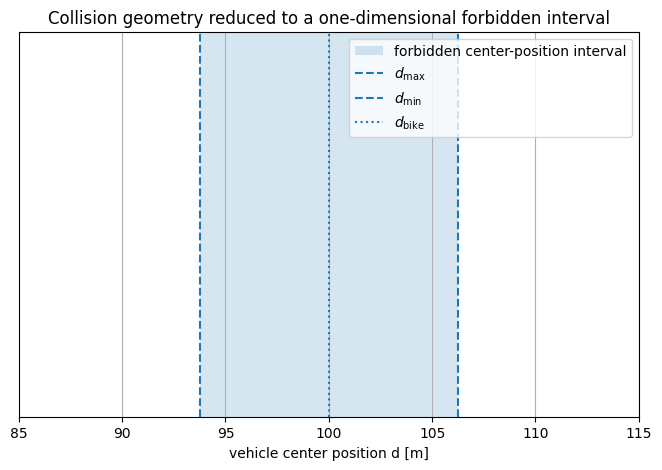

In [3]:
plt.figure()

plt.axvspan(d_max, d_min, alpha=0.18, label="forbidden center-position interval")
plt.axvline(d_max, linestyle="--", label=r"$d_{\max}$")
plt.axvline(d_min, linestyle="--", label=r"$d_{\min}$")
plt.axvline(d_bike, linestyle=":", label=r"$d_{\mathrm{bike}}$")

plt.xlim(85, 115)
plt.ylim(-1, 1)
plt.yticks([])
plt.xlabel("vehicle center position d [m]")
plt.title("Collision geometry reduced to a one-dimensional forbidden interval")
plt.legend()
plt.show()


## I.3 Why the safe set is nonconvex

During bicycle occupancy, the collision-free set for the vehicle center is

$$
\mathcal S_{\mathrm{safe}}
=
(-\infty,d_{\max}]
\cup
[d_{\min},\infty).
$$

It is the union of two convex half-lines, but the union itself is nonconvex.

Take

$$
d^{(1)}=d_{\max}-1,
\qquad
d^{(2)}=d_{\min}+1.
$$

Both are safe.

Their midpoint is

$$
\frac{d^{(1)}+d^{(2)}}{2}
=
d_{\mathrm{bike}},
$$

which lies inside the conflict region and is unsafe.

Thus a convex combination of two safe points need not be safe.

This simple geometric fact is the reason a binary/logical decision naturally appears.


<a id="part-2"></a>
# Part II — Vehicle model

## II.1 Continuous-time longitudinal dynamics

We use a point-mass longitudinal model

$$
\dot d(t)=v(t),
$$

$$
\dot v(t)=a(t).
$$

The state is

$$
x=
\begin{bmatrix}
d\\v
\end{bmatrix},
$$

and the control input is acceleration

$$
u=a.
$$


## II.2 Discretization

We discretize with explicit Euler and $T_s=1$ s:

$$
\boxed{
d_{k+1}=d_k+T_sv_k,
}
$$

$$
\boxed{
v_{k+1}=v_k+T_sa_k.
}
$$

Therefore

$$
x_{k+1}=Ax_k+Ba_k
$$

with

$$
A=
\begin{bmatrix}
1&T_s\\
0&1
\end{bmatrix},
\qquad
B=
\begin{bmatrix}
0\\T_s
\end{bmatrix}.
$$

A subtle consequence is that the acceleration $a_k$ changes the **next velocity** but does not
directly enter $d_{k+1}$ in this discretization.


In [4]:
Ts = 1.0

A_euler, B_euler = vehicle_matrices(
    Ts=Ts,
    discretization="euler",
)

print("A =")
print(A_euler)
print("\nB =")
print(B_euler)


A =
[[1. 1.]
 [0. 1.]]

B =
[[0.]
 [1.]]


### Modeling extension — exact zero-order-hold discretization

Explicit Euler is not the only possible choice.

For the continuous double integrator with acceleration held constant over one sample, the exact
zero-order-hold discretization is

$$
d_{k+1}
=
d_k+T_sv_k+\frac12T_s^2a_k,
$$

$$
v_{k+1}
=
v_k+T_sa_k,
$$

so

$$
B_{\mathrm{ZOH}}
=
\begin{bmatrix}
\frac12T_s^2\\
T_s
\end{bmatrix}.
$$

We keep the simpler Euler update throughout this notebook, and Part VI derives closed-form
reachability results for it. The trade-off is accuracy: because the horizon is short and $T_s=1$ s,
the discretization choice can visibly shift feasibility boundaries (see Exercise 8).

For standard discrete-time modeling discussions, see a digital-control text such as Franklin,
Powell & Workman; vehicle-modeling context is also discussed in Rajamani,
*Vehicle Dynamics and Control*.


In [5]:
_, B_zoh = vehicle_matrices(
    Ts=Ts,
    discretization="zoh",
)

print("Euler B:")
print(B_euler)
print("\nExact ZOH B:")
print(B_zoh)


Euler B:
[[0.]
 [1.]]

Exact ZOH B:
[[0.5]
 [1. ]]


<a id="part-3"></a>
# Part III — Constraints and objective

## III.1 Speed constraints

We impose

$$
\boxed{
0\le v_k\le v_{\max},
}
$$

with

$$
v_{\max}=32\ \mathrm{m/s}.
$$

The lower bound prevents reversing in this simplified one-dimensional scene.


## III.2 Friction-limited acceleration

The acceleration is bounded by

$$
\boxed{
-\mu g
\le
a_k
\le
\mu g.
}
$$

For

$$
\mu=0.10,
$$

the available magnitude is

$$
|a_k|
\le
0.981\ \mathrm{m/s^2}.
$$

For

$$
\mu=0.05,
$$

it becomes only

$$
|a_k|
\le
0.4905\ \mathrm{m/s^2}.
$$

This is an intentionally simplified friction model:

- acceleration and braking limits are symmetric;
- $\mu$ is known and constant;
- aerodynamic drag and powertrain limits are ignored;
- combined longitudinal/lateral tire usage is ignored.

Those assumptions are acceptable for this pedagogical CFTOC example, but they should not be
confused with a full vehicle/tire model.


In [6]:
g = 9.81

for mu in [0.10, 0.05]:
    print(
        f"mu={mu:0.2f} -> acceleration interval "
        f"[{-mu*g:0.4f}, {mu*g:0.4f}] m/s^2"
    )


mu=0.10 -> acceleration interval [-0.9810, 0.9810] m/s^2
mu=0.05 -> acceleration interval [-0.4905, 0.4905] m/s^2


## III.3 Cost function

We use the weights

$$
R=1,
\qquad
Q=3,
\qquad
P=3,
$$

and reference speed

$$
v_{\mathrm{ref}}=20\ \mathrm{m/s}.
$$

The finite-horizon objective is

$$
\boxed{
J
=
\sum_{k=0}^{N-1}
R a_k^2
+
\sum_{k=0}^{N-1}
Q(v_k-v_{\mathrm{ref}})^2
+
P(v_N-v_{\mathrm{ref}})^2.
}
$$

Interpretation:

- $Ra_k^2$ penalizes aggressive acceleration/braking;
- $Q(v_k-v_{\mathrm{ref}})^2$ rewards speed tracking during the maneuver;
- $P(v_N-v_{\mathrm{ref}})^2$ penalizes terminal speed error.

The position does not appear directly in the cost.
Position enters through the collision-avoidance constraints.


<a id="part-4"></a>
# Part IV — The logical maneuver choice

## IV.1 Two convex strategy problems

If the strategy is fixed in advance, each problem is a convex QP.

### Yield strategy

During bicycle occupancy,

$$
\boxed{
d_k\le d_{\max}.
}
$$

### Pass strategy

During bicycle occupancy,

$$
\boxed{
d_k\ge d_{\min}.
}
$$

For either fixed strategy:

- dynamics are linear;
- state/input constraints are linear;
- the objective is convex quadratic.

The nonconvexity appears only when we ask the optimizer to choose **between** the two alternatives.


## IV.2 A compact formulation with a binary variable

Introduce a binary strategy variable $s\in\{0,1\}$ and associate

$$
s=1
$$

with the yield strategy and

$$
s=0
$$

with the pass strategy.

A compact Big-M expression is

$$
\boxed{
(1-s)d_{\min}
\le
d_k
\le
d_{\max}+(1-s)D,
}
$$

for each conflict time, with a sufficiently large positive constant $D$.

If $s=1$:

$$
0\le d_k\le d_{\max},
$$

so the yield-side upper bound is active.

If $s=0$:

$$
d_{\min}\le d_k\le d_{\max}+D,
$$

so the pass-side lower bound is active while the upper bound is intended to become inactive.

The lower bound $0\le d_k$ in the yield case relies on the scene's nonnegative longitudinal
coordinate convention.


## IV.3 A more general symmetric Big-M encoding

A standard alternative is

$$
d_k
\le
d_{\max}
+
M(1-s),
$$

$$
d_k
\ge
d_{\min}
-
Ms.
$$

Then:

### $s=1$ — yield

$$
d_k\le d_{\max},
$$

while the pass constraint is relaxed to

$$
d_k\ge d_{\min}-M.
$$

### $s=0$ — pass

$$
d_k\ge d_{\min},
$$

while the yield constraint is relaxed to

$$
d_k\le d_{\max}+M.
$$

Because the objective is quadratic and $s$ is binary, this specific formulation is a
**mixed-integer quadratic program (MIQP)**.

The broader term **mixed-integer problem (MIP)** is also common.


## IV.4 Why “very large Big-M” is not mathematically free

A valid $M$ must be large enough to deactivate the inactive branch.

But an unnecessarily huge value can:

- weaken the continuous relaxation used inside branch-and-bound;
- worsen numerical conditioning;
- make solver tolerances more troublesome;
- slow mixed-integer optimization.

A generous round value such as $M=5000$ is valid here, because every reachable position lies
within a few hundred meters of the conflict region. That is simple and adequate for a small
illustrative example.

In production hybrid MPC, one normally derives the smallest valid bounds available from the known
state/input envelope.

For systematic treatments of logical constraints in predictive control, see Borrelli, Bemporad &
Morari, *Predictive Control for Linear and Hybrid Systems*, and Bemporad & Morari (1999).


## IV.5 Why we solve two QPs instead

There is only one binary decision:

$$
s\in\{0,1\}.
$$

Therefore the mixed problem is exactly

$$
\min
\left\{
J_{\mathrm{yield}}^\star,
J_{\mathrm{pass}}^\star
\right\},
$$

where infeasible alternatives are discarded.

So we can:

1. solve the yield QP;
2. solve the pass QP;
3. choose the lower-cost feasible solution.

For two modes, this is transparent, solver-independent, and mathematically equivalent to exhaustive
enumeration of the binary variable.

It would not scale well to dozens of binary decisions, where enumeration would require up to

$$
2^m
$$

mode combinations.


<a id="part-5"></a>
# Part V — The nominal scenario

## V.1 Which yield condition? Geometric versus center-line bound

There are two natural ways to write the yield condition.

### Geometric yield condition

Yielding uses

$$
d_k\le d_{\max}
=
d_{\mathrm{bike}}
-\frac{l_{\mathrm{car}}+w_{\mathrm{bike}}}{2}.
$$

This explicitly includes the vehicle/crossing geometry.

### Looser center-line condition

A simpler variant only requires the vehicle center not to have passed the center of the crossing
at the terminal step,

$$
d_N\le d_{\mathrm{bike}}
$$

for the yield branch.

That is a **looser condition** than the geometric collision-free bound.

In both cases, no terminal-speed constraint is imposed by default, so the yield branch does
**not** enforce

$$
v_N=0.
$$

Accordingly, we use the geometrically collision-free $d_{\max}$ as the default and label the
looser center-line condition explicitly whenever it is used (Part IX).

We do not silently treat “yield” as “full stop.”


## V.2 A horizon that ends when the bicycle arrives

The nominal scenario sets

$$
T=t_{\min}=4\ \mathrm{s}.
$$

Thus the finite-horizon problem terminates exactly when the bicycle begins entering the intersection.

In this special case, the strategy constraint is imposed only at

$$
k=N.
$$

More generally, the maneuver must hold throughout an occupancy window

$$
k\in[t_{\min},t_{\max}].
$$

We first study the terminal-time structure, then extend it to a full window in Part X.


In [7]:
x0 = np.array([60.0, 5.0])

nominal_parameters = dict(
    N=4,
    Ts=1.0,
    mu=0.10,
    v_max=32.0,
    v_ref=20.0,
    Qv=3.0,
    Ru=1.0,
    Pv=3.0,
    discretization="euler",
    yield_boundary="geometric",
)

best, solutions = choose_collision_strategy(
    x0,
    **nominal_parameters,
)

for sol in solutions:
    print(
        f"{sol.strategy:5s}: "
        f"feasible={sol.success}, "
        f"cost={sol.objective}, "
        f"terminal state={sol.X[-1]}"
    )

print("\nselected strategy:",
      None if best is None else best.strategy)


yield: feasible=True, cost=2582.5619340000003, terminal state=[85.886  8.924]
pass : feasible=False, cost=inf, terminal state=[85.886  8.924]

selected strategy: yield


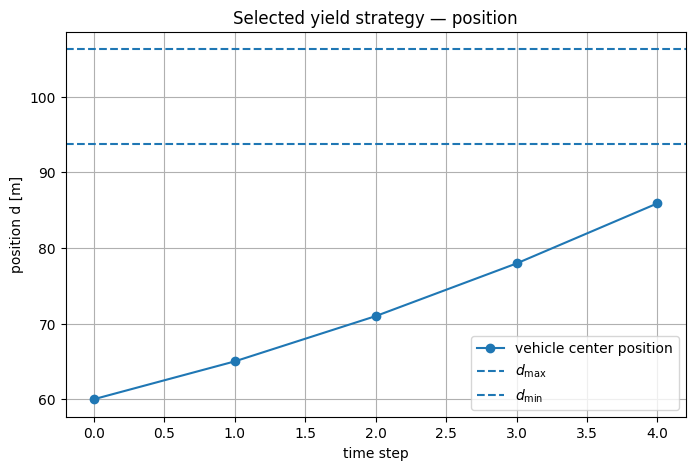

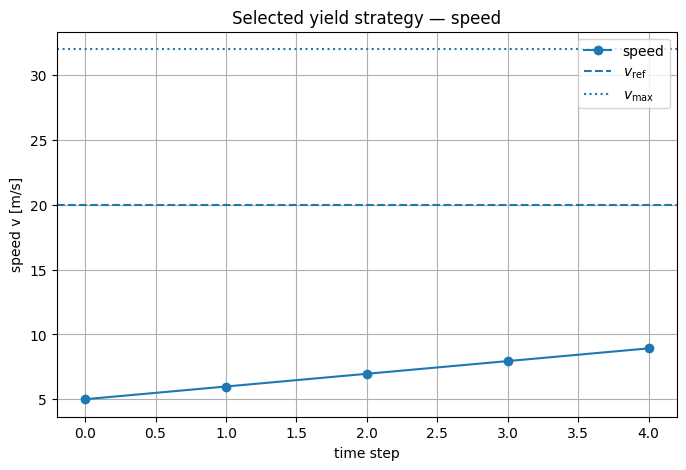

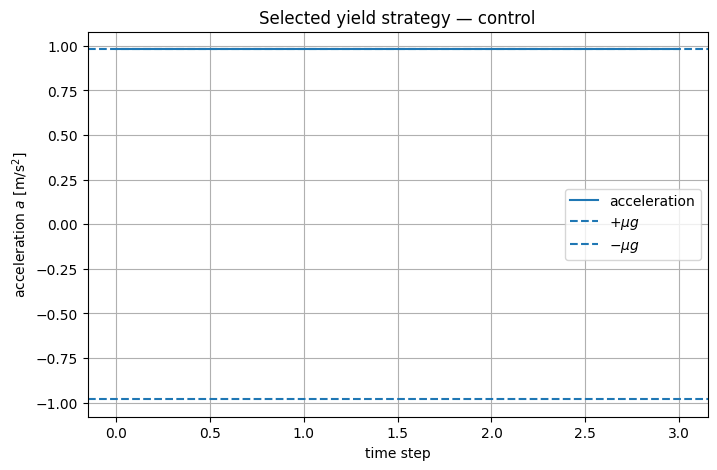

In [8]:
if best is None:
    raise RuntimeError("Expected at least one feasible strategy.")

t_state = np.arange(best.X.shape[0])
t_input = np.arange(best.U.shape[0])

plt.figure()
plt.plot(t_state, best.X[:, 0], marker="o", label="vehicle center position")
plt.axhline(d_max, linestyle="--", label=r"$d_{\max}$")
plt.axhline(d_min, linestyle="--", label=r"$d_{\min}$")
plt.xlabel("time step")
plt.ylabel("position d [m]")
plt.title(f"Selected {best.strategy} strategy — position")
plt.legend()
plt.show()

plt.figure()
plt.plot(t_state, best.X[:, 1], marker="o", label="speed")
plt.axhline(20.0, linestyle="--", label=r"$v_{\mathrm{ref}}$")
plt.axhline(32.0, linestyle=":", label=r"$v_{\max}$")
plt.xlabel("time step")
plt.ylabel("speed v [m/s]")
plt.title(f"Selected {best.strategy} strategy — speed")
plt.legend()
plt.show()

plt.figure()
plt.step(t_input, best.U[:, 0], where="post", label="acceleration")
plt.axhline(0.10 * g, linestyle="--", label=r"$+\mu g$")
plt.axhline(-0.10 * g, linestyle="--", label=r"$-\mu g$")
plt.xlabel("time step")
plt.ylabel(r"acceleration $a$ [m/s$^2$]")
plt.title(f"Selected {best.strategy} strategy — control")
plt.legend()
plt.show()


## V.3 Why the pass maneuver is impossible from this initial condition

For

$$
x_0=
\begin{bmatrix}
60\\5
\end{bmatrix},
$$

even maximum acceleration over the short horizon cannot move the vehicle center beyond

$$
d_{\min}=106.25\ \mathrm m
$$

by $t=4$ s under the explicit-Euler model.

We can see this directly from the dynamics rather than relying only on the numerical solver.


<a id="part-6"></a>
# Part VI — Analytical reachability under the Euler model

## VI.1 Closed-form velocity

From

$$
v_{k+1}=v_k+T_sa_k,
$$

we obtain

$$
\boxed{
v_k
=
v_0
+
T_s
\sum_{j=0}^{k-1}a_j.
}
$$


## VI.2 Closed-form terminal position

Using

$$
d_{k+1}=d_k+T_sv_k,
$$

we have

$$
d_N
=
d_0
+
T_s\sum_{k=0}^{N-1}v_k.
$$

Substituting the velocity expansion,

$$
\boxed{
d_N
=
d_0
+
NT_sv_0
+
T_s^2
\sum_{j=0}^{N-2}
(N-1-j)a_j.
}
$$

Notice:

$$
\boxed{
a_{N-1}
\text{ does not affect }d_N
}
$$

under the explicit-Euler position update.

It affects $v_N$, but the final position has already been computed from $v_{N-1}$.

That is a discretization-specific property and is worth understanding before interpreting the
optimization results.


## VI.3 Terminal-position extrema when speed bounds are inactive

Let

$$
a_{\max}=\mu g.
$$

To maximize terminal position, set all position-relevant accelerations to $+a_{\max}$.

To minimize it, set them to $-a_{\max}$.

Because

$$
\sum_{r=1}^{N-1}r
=
\frac{N(N-1)}{2},
$$

we obtain

$$
\boxed{
d_N^{\max}
=
d_0+NT_sv_0
+
\mu gT_s^2
\frac{N(N-1)}{2},
}
$$

and

$$
\boxed{
d_N^{\min}
=
d_0+NT_sv_0
-
\mu gT_s^2
\frac{N(N-1)}{2}.
}
$$

These formulas are exact for the Euler model **provided the speed constraints do not become
active**.


In [9]:
d_lo, d_hi = terminal_position_extrema_no_speed_limits(
    x0,
    N=4,
    Ts=1.0,
    mu=0.10,
)

print("analytic d_4 minimum =", d_lo)
print("analytic d_4 maximum =", d_hi)
print("yield boundary       =", d_max)
print("pass boundary        =", d_min)


analytic d_4 minimum = 74.114
analytic d_4 maximum = 85.886
yield boundary       = 93.75
pass boundary        = 106.25


The maximum reachable terminal position is still below $d_{\min}$, so passing is dynamically
impossible under the modeled constraints.

The yield branch is feasible.

This provides an analytical explanation of the solver result.


## VI.4 Width of the controllable terminal-position interval

Ignoring active speed bounds,

$$
d_N^{\max}-d_N^{\min}
=
\boxed{
\mu gT_s^2N(N-1).
}
$$

The forbidden spatial gap has width

$$
d_{\min}-d_{\max}
=
l_{\mathrm{car}}+w_{\mathrm{bike}}.
$$

Therefore a necessary geometric condition for **some initial state** to have both terminal
strategies reachable under this simplified calculation is

$$
\mu gT_s^2N(N-1)
\ge
l_{\mathrm{car}}+w_{\mathrm{bike}}.
$$

This gives the critical value

$$
\boxed{
\mu_{\mathrm{crit}}
=
\frac{l_{\mathrm{car}}+w_{\mathrm{bike}}}
{gT_s^2N(N-1)}.
}
$$

This threshold follows directly from the simplified reachability calculation above.


In [10]:
N = 4

mu_crit = (
    (l_car + w_bike)
    / (g * Ts**2 * N * (N - 1))
)

width_mu_010 = 0.10 * g * Ts**2 * N * (N - 1)
width_mu_012 = 0.12 * g * Ts**2 * N * (N - 1)

print("critical mu (ignoring speed-bound activation):", mu_crit)
print("reachable terminal-position width at mu=0.10:", width_mu_010)
print("reachable terminal-position width at mu=0.12:", width_mu_012)
print("forbidden geometric gap:", l_car + w_bike)


critical mu (ignoring speed-bound activation): 0.10618416581719334
reachable terminal-position width at mu=0.10: 11.772000000000002
reachable terminal-position width at mu=0.12: 14.1264
forbidden geometric gap: 12.5


For the geometry of Part I,

$$
\mu_{\mathrm{crit}}
\approx 0.106.
$$

So at

$$
\mu=0.10
$$

the control authority is slightly too small for the two geometric strategy-feasible regions to
overlap in this simplified no-speed-saturation calculation.

At

$$
\mu=0.12,
$$

overlap can occur.

This becomes useful when studying how the objective chooses between two simultaneously feasible
maneuvers.


<a id="part-7"></a>
# Part VII — Friction and feasibility

## VII.1 A set-inclusion argument

Let

$$
\mathcal U(\mu)
=
[-\mu g,\mu g].
$$

If

$$
0<\mu_1<\mu_2,
$$

then

$$
\boxed{
\mathcal U(\mu_1)
\subset
\mathcal U(\mu_2).
}
$$

Every input sequence feasible under the lower-friction model is also admissible under the
higher-friction model.

Therefore, with all other modeling assumptions unchanged,

$$
\boxed{
\mathcal F(\mu_1)
\subseteq
\mathcal F(\mu_2),
}
$$

where $\mathcal F(\mu)$ denotes the set of initial conditions for which at least one modeled
collision-avoidance strategy is feasible.

So the statement

> lower friction enlarges the infeasible region

is not just an empirical observation from a plot; it follows directly from feasible-set inclusion.


## VII.2 Strategy maps over initial conditions

We now solve the CFTOC over a grid of initial conditions

$$
(d_0,v_0).
$$

Instead of showing only the selected strategy, we keep **two maps**:

1. number of feasible strategies: 0, 1, or 2;
2. the lower-cost strategy among feasible alternatives.

This separates feasibility from preference.


### How to read the maps

Each small colored rectangle corresponds to **one initial condition**

$$
x_0=
\begin{bmatrix}
d_0\\v_0
\end{bmatrix}.
$$

The horizontal axis is the initial vehicle position $d_0$ and the vertical axis is the initial
speed $v_0$.

The first map does **not** show the optimal maneuver. It shows **how many of the two modeled
maneuvers are feasible**:

- `0` = neither yield nor pass is feasible;
- `1` = exactly one of the two maneuvers is feasible;
- `2` = both yield and pass are feasible.

The second map shows the **lower-cost feasible maneuver**:

- `-1` = neither maneuver is feasible;
- `0` = yield has the lower optimal cost;
- `1` = pass has the lower optimal cost.

The numerical labels on the color bar are the important part. The actual displayed colors are only
a plotting aid and have no physical meaning.


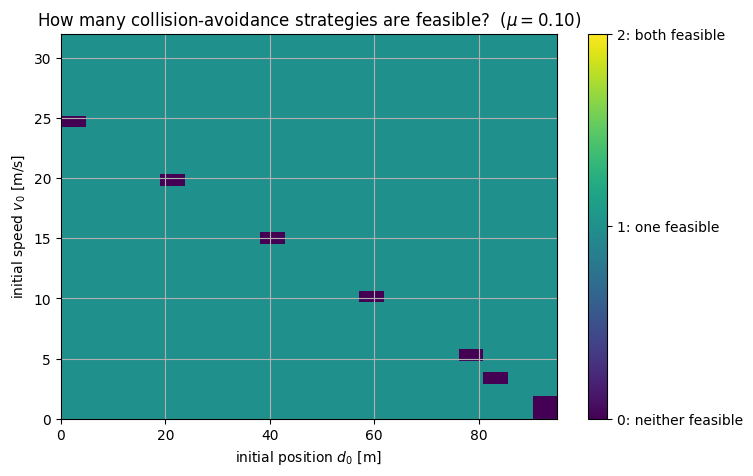

In [11]:
d_values = np.arange(0.0, 100.0, 5.0)
v_values = np.arange(0.0, 33.0, 1.0)

count_mu_010, best_mu_010 = strategy_grid(
    d_values,
    v_values,
    N=4,
    Ts=1.0,
    mu=0.10,
    v_max=32.0,
    v_ref=20.0,
    Qv=3.0,
    Ru=1.0,
    Pv=3.0,
    discretization="euler",
    yield_boundary="geometric",
)

plt.figure()
img = plt.imshow(
    count_mu_010,
    origin="lower",
    aspect="auto",
    extent=[
        d_values[0], d_values[-1],
        v_values[0], v_values[-1]
    ],
    vmin=0,
    vmax=2,
)
cbar = plt.colorbar(img, ticks=[0, 1, 2])
cbar.ax.set_yticklabels([
    "0: neither feasible",
    "1: one feasible",
    "2: both feasible",
])
plt.xlabel(r"initial position $d_0$ [m]")
plt.ylabel(r"initial speed $v_0$ [m/s]")
plt.title(r"How many collision-avoidance strategies are feasible?  ($\mu=0.10$)")
plt.show()


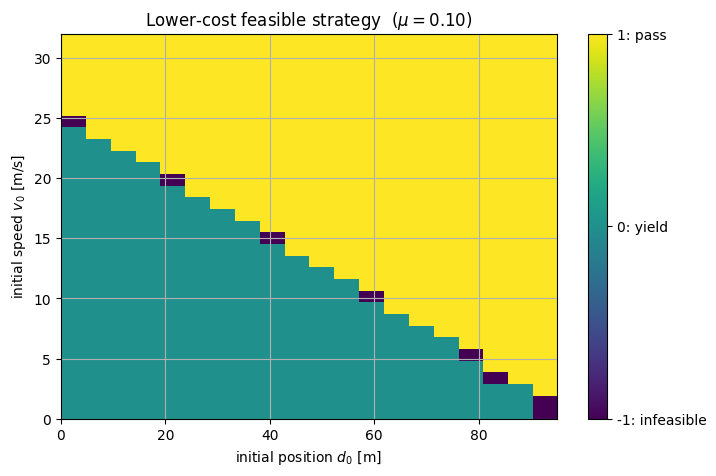

In [12]:
plt.figure()
img = plt.imshow(
    best_mu_010,
    origin="lower",
    aspect="auto",
    extent=[
        d_values[0], d_values[-1],
        v_values[0], v_values[-1]
    ],
    vmin=-1,
    vmax=1,
)
cbar = plt.colorbar(img, ticks=[-1, 0, 1])
cbar.ax.set_yticklabels([
    "-1: infeasible",
    "0: yield",
    "1: pass",
])
plt.xlabel(r"initial position $d_0$ [m]")
plt.ylabel(r"initial speed $v_0$ [m/s]")
plt.title(r"Lower-cost feasible strategy  ($\mu=0.10$)")
plt.show()


## VII.3 Lower friction

Repeat the same experiment at

$$
\mu=0.05.
$$


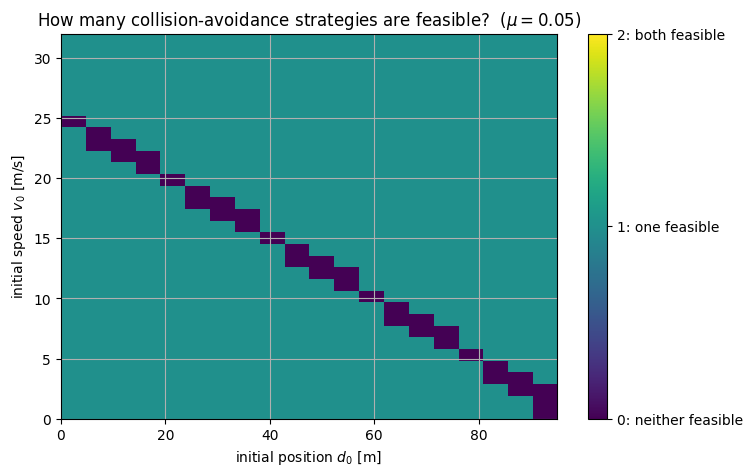

In [13]:
count_mu_005, best_mu_005 = strategy_grid(
    d_values,
    v_values,
    N=4,
    Ts=1.0,
    mu=0.05,
    v_max=32.0,
    v_ref=20.0,
    Qv=3.0,
    Ru=1.0,
    Pv=3.0,
    discretization="euler",
    yield_boundary="geometric",
)

plt.figure()
img = plt.imshow(
    count_mu_005,
    origin="lower",
    aspect="auto",
    extent=[
        d_values[0], d_values[-1],
        v_values[0], v_values[-1]
    ],
    vmin=0,
    vmax=2,
)
cbar = plt.colorbar(img, ticks=[0, 1, 2])
cbar.ax.set_yticklabels([
    "0: neither feasible",
    "1: one feasible",
    "2: both feasible",
])
plt.xlabel(r"initial position $d_0$ [m]")
plt.ylabel(r"initial speed $v_0$ [m/s]")
plt.title(r"How many collision-avoidance strategies are feasible?  ($\mu=0.05$)")
plt.show()


In [14]:
n_grid = count_mu_010.size

infeasible_010 = np.sum(count_mu_010 == 0)
infeasible_005 = np.sum(count_mu_005 == 0)

print(
    f"mu=0.10: {infeasible_010}/{n_grid} "
    f"grid states have neither modeled strategy feasible"
)
print(
    f"mu=0.05: {infeasible_005}/{n_grid} "
    f"grid states have neither modeled strategy feasible"
)
print(
    "infeasible states increased by",
    infeasible_005 - infeasible_010
)


mu=0.10: 8/660 grid states have neither modeled strategy feasible
mu=0.05: 36/660 grid states have neither modeled strategy feasible
infeasible states increased by 28


The lower-$\mu$ feasible set cannot become larger under this model, because the admissible control
set has contracted.

The grid count above illustrates this; the set-inclusion argument of VII.1 guarantees it for every
initial state, not only for the grid points.


<a id="part-8"></a>
# Part VIII — What do $Q$, $R$, and $P$ actually change?

## VIII.1 Objective weights do not change feasibility

For a fixed:

- dynamic model;
- horizon;
- state constraints;
- input constraints;
- collision constraints;

changing

$$
Q,\;R,\;P
$$

changes only the objective.

Therefore it cannot create or destroy feasible trajectories.

In exact optimization,

$$
\boxed{
\text{feasible set is independent of }Q,R,P.
}
$$

What the weights **can** change is which feasible trajectory is optimal, and—if both maneuver
branches are feasible—which strategy has lower cost.

This distinction is important when interpreting a strategy map.


## VIII.2 A state where both strategies are feasible

Use a slightly larger friction coefficient

$$
\mu=0.15
$$

and initial state

$$
x_0=
\begin{bmatrix}
30\\17
\end{bmatrix}.
$$

For this state, both geometric strategies are feasible.

We now vary only the input penalty $R$.


In [15]:
x_trade = np.array([30.0, 17.0])
mu_trade = 0.15

for Ru in [0.1, 1.0, 1000.0]:
    best_trade, sols_trade = choose_collision_strategy(
        x_trade,
        N=4,
        Ts=1.0,
        mu=mu_trade,
        v_max=32.0,
        v_ref=20.0,
        Qv=3.0,
        Ru=Ru,
        Pv=3.0,
        discretization="euler",
        yield_boundary="geometric",
    )

    print(f"\nR={Ru}")
    for sol in sols_trade:
        print(
            f"  {sol.strategy:5s}: "
            f"feasible={sol.success}, "
            f"cost={sol.objective:.3f}, "
            f"sum(a^2)={np.sum(sol.U[:,0]**2):.3f}"
        )

    print("  chosen:", best_trade.strategy)



R=0.1
  yield: feasible=True, cost=220.800, sum(a^2)=6.923
  pass : feasible=True, cost=36.693, sum(a^2)=5.781
  chosen: pass

R=1.0
  yield: feasible=True, cost=226.877, sum(a^2)=6.225
  pass : feasible=True, cost=41.764, sum(a^2)=5.520
  chosen: pass

R=1000.0
  yield: feasible=True, cost=1563.444, sum(a^2)=1.291
  pass : feasible=True, cost=5165.382, sum(a^2)=5.127
  chosen: yield


With a small control-effort penalty, speed tracking dominates and one strategy can be preferred.

With a very large $R$, the optimizer strongly prefers the branch requiring less acceleration/braking
effort, and the selected maneuver can change.

But both branches remain feasible throughout the experiment.

That is the correct separation:

$$
\boxed{
\mu
\text{ changes control authority and feasibility;}
}
$$

$$
\boxed{
Q,R,P
\text{ change preference among feasible solutions.}
}
$$


<a id="part-9"></a>
# Part IX — “Yield” is not automatically “stop”

## IX.1 Three distinct mathematical statements

These are often conflated in casual language.

### A. Geometric yield

$$
d_N\le d_{\max}.
$$

The vehicle remains on the safe near side at the terminal conflict time.

### B. Full stop before the conflict region

$$
d_N\le d_{\max},
\qquad
v_N=0.
$$

This is strictly more restrictive.

### C. Looser center-line condition

The center-line variant of V.1 uses

$$
d_N\le d_{\mathrm{bike}},
$$

which is looser than the geometric bound because

$$
d_{\mathrm{bike}}>d_{\max}.
$$

We keep these three conditions separate instead of calling all three “stop.”


In [16]:
x_stop_demo = np.array([60.0, 5.0])

geometric_yield = solve_collision_strategy(
    x_stop_demo,
    "yield",
    N=4,
    mu=0.10,
    terminal_stop=False,
    yield_boundary="geometric",
)

full_stop = solve_collision_strategy(
    x_stop_demo,
    "yield",
    N=4,
    mu=0.10,
    terminal_stop=True,
    yield_boundary="geometric",
)

centerline_yield = solve_collision_strategy(
    x_stop_demo,
    "yield",
    N=4,
    mu=0.10,
    terminal_stop=False,
    yield_boundary="center_line",
)

print("geometric yield feasible :", geometric_yield.success)
print("full stop feasible       :", full_stop.success)
print("center-line feasible     :", centerline_yield.success)

if geometric_yield.success:
    print("geometric-yield terminal state:", geometric_yield.X[-1])

if centerline_yield.success:
    print("center-line terminal state:", centerline_yield.X[-1])


geometric yield feasible : True
full stop feasible       : False
center-line feasible     : True
geometric-yield terminal state: [85.886  8.924]
center-line terminal state: [85.886  8.924]


From this state, the vehicle can remain before the geometric conflict region but cannot reduce its
speed all the way to zero within four seconds under the friction-limited acceleration bound.

Thus

$$
\boxed{
\text{yield feasible}
\not\Rightarrow
\text{full stop feasible}.
}
$$


<a id="part-10"></a>
# Part X — General bicycle-occupancy window

## X.1 From a terminal-time condition to a time-indexed safety condition

The nominal scenario of Part V terminates at

$$
T=t_{\min}.
$$

Suppose instead that the bicycle occupies the conflict region over

$$
t\in[t_{\min},t_{\max}],
$$

for example

$$
t_{\min}=4,
\qquad
t_{\max}=6,
$$

and our horizon continues beyond that interval.

Then yield should impose

$$
\boxed{
d_k\le d_{\max},
\qquad
k=4,5,6,
}
$$

not merely at the first conflict instant.

Likewise, the pass strategy requires

$$
d_k\ge d_{\min}
$$

throughout the conflict interval.

With the model constraint $v_k\ge0$, once the vehicle has passed beyond $d_{\min}$ it cannot move
backward, so the later pass inequalities are redundant but harmless.
For the yield branch, however, enforcing the full occupancy window is essential.


In [17]:
x_window = np.array([60.0, 5.0])

window_best, window_solutions = choose_collision_strategy(
    x_window,
    N=8,
    Ts=1.0,
    conflict_steps=(4, 5, 6),
    mu=0.10,
    v_max=32.0,
    v_ref=20.0,
    Qv=3.0,
    Ru=1.0,
    Pv=3.0,
    discretization="euler",
    yield_boundary="geometric",
)

for sol in window_solutions:
    print(
        f"{sol.strategy:5s}: "
        f"feasible={sol.success}, "
        f"cost={sol.objective}"
    )

print(
    "selected:",
    None if window_best is None else window_best.strategy
)


yield: feasible=True, cost=4729.999548177444
pass : feasible=False, cost=inf
selected: yield


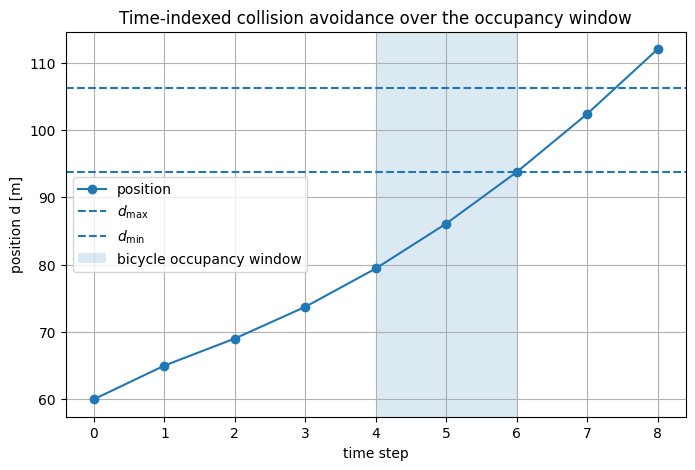

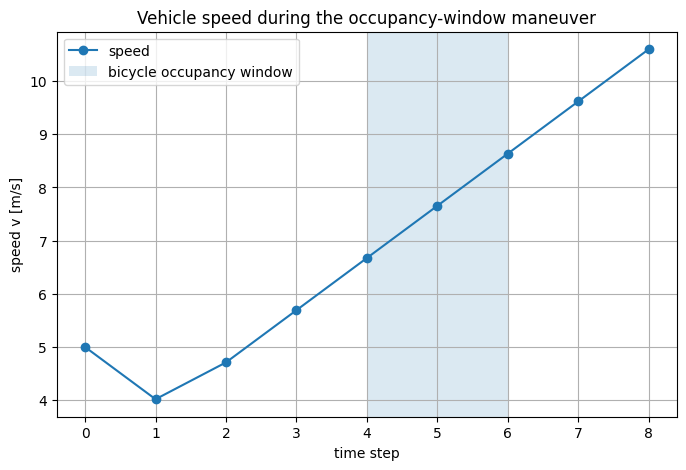

In [18]:
if window_best is not None:
    t = np.arange(window_best.X.shape[0])

    plt.figure()
    plt.plot(t, window_best.X[:, 0], marker="o", label="position")
    plt.axhline(d_max, linestyle="--", label=r"$d_{\max}$")
    plt.axhline(d_min, linestyle="--", label=r"$d_{\min}$")
    plt.axvspan(4, 6, alpha=0.16, label="bicycle occupancy window")
    plt.xlabel("time step")
    plt.ylabel("position d [m]")
    plt.title("Time-indexed collision avoidance over the occupancy window")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, window_best.X[:, 1], marker="o", label="speed")
    plt.axvspan(4, 6, alpha=0.16, label="bicycle occupancy window")
    plt.xlabel("time step")
    plt.ylabel("speed v [m/s]")
    plt.title("Vehicle speed during the occupancy-window maneuver")
    plt.legend()
    plt.show()


## X.2 Why one binary variable is meaningful here

Using one strategy variable $s$ for the entire occupancy window means the controller commits to one
topological maneuver:

- stay on the near side for the full conflict interval; or
- be on the far side for the full conflict interval.

If independent binary variables $s_k$ were introduced carelessly at every time step, the optimizer
could switch branches across time.

That could permit a sequence that is “yield-side” at one conflict instant and “pass-side” at a
later instant, which physically means traversing the forbidden interval while the bicycle is still
present.

Logical variables must therefore encode the **maneuver-level logic**, not merely individual inequalities.


<a id="part-11"></a>
# Part XI — Interpreting infeasibility

## XI.1 “Neither strategy is feasible” has a precise but limited meaning

If both QPs are infeasible, then under this model there is no admissible acceleration sequence
satisfying either modeled maneuver.

That does **not** prove that a collision is physically unavoidable in the real world.

The model excludes possibilities such as:

- steering around the bicycle;
- the bicycle reacting;
- changing the bicycle trajectory;
- leaving the lane;
- emergency maneuvers outside the modeled acceleration envelope.

The correct statement is:

$$
\boxed{
\text{neither modeled longitudinal strategy is feasible under the stated assumptions.}
}
$$

That qualification matters in safety analysis.


<a id="part-12"></a>
# Part XII — Model limitations and extensions

## XII.1 Deterministic bicycle timing

The bicycle occupancy interval is treated as exactly known.

Real systems have uncertainty in:

- detection;
- velocity estimation;
- intent;
- future arrival time.

A robust formulation could require safety for all arrival times in a bounded uncertainty set.

A stochastic/chance-constrained formulation could instead impose a probabilistic risk bound.

Both are extensions beyond the deterministic model used in this notebook.


## XII.2 Friction uncertainty

The model assumes a known scalar $\mu$.

In reality, available tire-road friction may be uncertain and time-varying.

One conservative robust option would replace $\mu$ by a guaranteed lower bound

$$
\underline\mu.
$$

Then

$$
|a_k|
\le
\underline\mu g
$$

guarantees feasibility against every friction value in the assumed interval

$$
\mu\ge\underline\mu.
$$

This gains robustness at the price of a smaller feasible region.

More sophisticated vehicle models can use friction-circle/ellipse constraints and combined-slip tire
models. Rajamani's *Vehicle Dynamics and Control* is a useful entry point; Pacejka's tire-dynamics
texts go substantially deeper.


## XII.3 One-dimensional point-mass model

The model intentionally omits:

- steering;
- lateral position;
- yaw dynamics;
- tire slip dynamics;
- actuator delay;
- state-estimation uncertainty.

This is a deliberate simplification, not a weakness of the example.

It isolates a very specific idea:

$$
\boxed{
\text{simple dynamics}
+
\text{logical environment constraint}
\Rightarrow
\text{hybrid/nonconvex optimal control}.
}
$$

That is the lesson to retain.


<a id="part-13"></a>
# Part XIII — Common pitfalls

## XIII.1 Pitfall: the double-integrator dynamics make the whole problem convex

No.

For a **fixed maneuver strategy**, the problem is a convex QP.

The union

$$
d\le d_{\max}
\quad\text{or}\quad
d\ge d_{\min}
$$

is nonconvex.

The logic, not the plant model, creates the nonconvexity.

---

## XIII.2 Pitfall: lower $\mu$ only changes comfort

No.

Because $\mu$ directly bounds the control input, it changes the reachable set and therefore
feasibility.

---

## XIII.3 Pitfall: changing $Q$ or $R$ changes the feasible region

Not if the constraints and model are unchanged.

Weights change optimality, not mathematical feasibility.

---

## XIII.4 Pitfall: “yield” means $v_N=0$

Only if

$$
v_N=0
$$

is explicitly imposed.

The nominal formulation imposes no terminal-speed constraint; a full stop must be requested
explicitly (Part IX).

---

## XIII.5 Pitfall: $d_N\le d_{\mathrm{bike}}$ is the same as geometric collision avoidance

No.

The geometry-derived safe bound is

$$
d_N\le d_{\max}<d_{\mathrm{bike}}.
$$

The center-line condition $d_N\le d_{\mathrm{bike}}$ is looser: it admits terminal positions in
$(d_{\max},d_{\mathrm{bike}}]$, where the front of the vehicle already overlaps the conflict region.

---

## XIII.6 Pitfall: an enormous Big-M can only help

A value that is too small can invalidate the formulation.
A value that is unnecessarily large can weaken and numerically degrade the mixed-integer problem.

---

## XIII.7 Pitfall: solver infeasibility means real-world collision is unavoidable

It means no solution exists within the **modeled dynamics, control bounds, strategies, and
prediction assumptions**.


<a id="part-14"></a>
# Part XIV — Check your understanding

Try to answer each question before opening its answer.

**1. How are $d_{\max}$ and $d_{\min}$ derived?**

<details>
<summary>Answer</summary>

By preventing overlap between the vehicle interval
$[d-l_{\rm car}/2,d+l_{\rm car}/2]$ and the bicycle conflict interval
$[d_{\rm bike}-w_{\rm bike}/2,d_{\rm bike}+w_{\rm bike}/2]$.

The two no-overlap cases give

$$
d\le d_{\rm bike}-\frac{l_{\rm car}+w_{\rm bike}}2
$$

or

$$
d\ge d_{\rm bike}+\frac{l_{\rm car}+w_{\rm bike}}2.
$$

</details>

**2. Why is the collision-free set nonconvex?**

<details>
<summary>Answer</summary>

It is a union of two separated half-lines. Two safe points taken on opposite sides can have an
unsafe midpoint inside the forbidden interval.

</details>

**3. Why is each fixed-strategy problem convex?**

<details>
<summary>Answer</summary>

The vehicle dynamics are linear, the state/input/strategy constraints become linear
inequalities after fixing the branch, and the objective is convex quadratic.

</details>

**4. What optimization class results when the binary strategy variable is included?**

<details>
<summary>Answer</summary>

With the quadratic objective and linear dynamics/constraints plus a binary variable, the problem is
an MIQP, a particular mixed-integer optimization problem.

</details>

**5. Why can we solve two QPs instead of an MIQP here?**

<details>
<summary>Answer</summary>

There is only one binary decision. Exhaustive enumeration of $s=0$ and $s=1$ gives exactly the
minimum of the two branch-optimal costs.

</details>

**6. What does $\mu$ do mathematically?**

<details>
<summary>Answer</summary>

It scales the admissible input interval:

$$
a\in[-\mu g,\mu g].
$$

Reducing $\mu$ creates a subset of the former control set, so the set of feasible initial states
cannot increase.

</details>

**7. Do $Q$, $R$, and $P$ change feasibility?**

<details>
<summary>Answer</summary>

No, not when only the objective weights change. They change which feasible trajectory/strategy is
optimal. Feasibility is determined by dynamics and constraints.

</details>

**8. What is unusual about the last acceleration under the explicit-Euler discretization?**

<details>
<summary>Answer</summary>

$a_{N-1}$ changes $v_N$ but not $d_N$, because the position update uses $v_{N-1}$ and contains no
direct acceleration term.

</details>

**9. Why is “yield” different from “stop”?**

<details>
<summary>Answer</summary>

Yield can mean only that the vehicle remains before the conflict region. Full stop additionally
requires $v_N=0$ or an equivalent stopping condition.

</details>

**10. Why must the yield constraint be enforced for the whole occupancy window in a longer-horizon problem?**

<details>
<summary>Answer</summary>

Being safe at the instant the bicycle enters does not prevent the vehicle from entering the
conflict region one step later while the bicycle is still present.

</details>

**11. What is the main danger of a large Big-M?**

<details>
<summary>Answer</summary>

Although a sufficiently large value deactivates the intended inequality, an excessive value weakens
the continuous relaxation and can cause poor numerical behavior and slow mixed-integer search.

</details>

**12. What does “both strategies infeasible” actually prove?**

<details>
<summary>Answer</summary>

Only that neither modeled longitudinal maneuver is possible within the chosen horizon and
constraints. It is not a universal proof that every physically possible collision-avoidance action
has failed.

</details>


<a id="part-15"></a>
# Part XV — Exercises

### Exercise 1 — Conflict geometry

Derive $d_{\max}$ and $d_{\min}$ from interval non-overlap.

Then show that

$$
d_{\min}-d_{\max}
=
l_{\mathrm{car}}+w_{\mathrm{bike}}.
$$

---

### Exercise 2 — Euler prediction

Starting from

$$
d_{k+1}=d_k+T_sv_k,
\qquad
v_{k+1}=v_k+T_sa_k,
$$

derive

$$
d_N
=
d_0+NT_sv_0
+
T_s^2
\sum_{j=0}^{N-2}(N-1-j)a_j.
$$

---

### Exercise 3 — Critical friction

Ignoring active speed constraints, derive

$$
\mu_{\mathrm{crit}}
=
\frac{l_{\mathrm{car}}+w_{\mathrm{bike}}}
{gT_s^2N(N-1)}.
$$

What does this quantity mean, and what does it **not** guarantee?

---

### Exercise 4 — Big-M

Starting from a binary variable $s$ with $s=1$ for yield and $s=0$ for pass, derive the symmetric
Big-M constraints

$$
d_k\le d_{\max}+M(1-s),
$$

$$
d_k\ge d_{\min}-Ms.
$$

For a known finite position envelope $d\in[d_{\rm low},d_{\rm high}]$, derive valid lower bounds
on $M$.

---

### Exercise 5 — Objective weights

Choose an initial state for which both strategies are feasible.

Vary only $R$.

Verify numerically that:

- feasibility does not change;
- the selected optimal strategy may change.

---

### Exercise 6 — Full stop

Add

$$
v_N=0
$$

to the yield branch.

Map the initial states for which full stop is feasible and compare them with the geometric-yield
feasible set.

---

### Exercise 7 — Occupancy window

Use

$$
t_{\min}=4,
\qquad
t_{\max}=6,
\qquad
N=8.
$$

Compare:

1. enforcing yield only at $t_{\min}$;
2. enforcing it at every step in the occupancy interval.

Find an initial state for which the first is feasible but the second is not.

---

### Exercise 8 — Discretization

Repeat the feasibility map with the exact ZOH double-integrator discretization

$$
B=
\begin{bmatrix}
T_s^2/2\\
T_s
\end{bmatrix}.
$$

Explain why the boundary moves.

---

### Exercise 9 — Friction uncertainty

Suppose

$$
\mu\in[0.05,0.10].
$$

Formulate a simple robust acceleration bound that guarantees admissibility for every value in this
interval.

Discuss its conservatism.

---

### Exercise 10 — Beyond one dimension

List the additional states, inputs, and constraints needed to allow the vehicle to steer around the
conflict region rather than only brake or accelerate longitudinally.


<a id="part-16"></a>
# Part XVI — Scope and references

**Scope.** This notebook treats vehicle–bicycle collision avoidance at a crossing as a
deterministic, one-dimensional constrained finite-time optimal-control problem. The vehicle is a
longitudinal point mass discretized with explicit Euler; acceleration is limited symmetrically by a
known friction coefficient, $|a_k|\le\mu g$, and speed by $0\le v_k\le v_{\max}$; the cost trades
speed tracking against acceleration effort; and the bicycle's occupancy of the conflict region is
known in advance (a single conflict instant in Parts V–IX, a window in Part X).

The disjunction “yield or pass” is solved exactly by enumerating two convex QPs. Along the way the
notebook covers the equivalent mixed-integer (Big-M) formulation, closed-form Euler reachability
bounds, the critical friction coefficient, and the limitations of the model. The yield branch uses
the geometric bound $d_{\max}=d_{\mathrm{bike}}-(l_{\mathrm{car}}+w_{\mathrm{bike}})/2$ by default;
the looser center-line condition $d_N\le d_{\mathrm{bike}}$, a terminal full stop $v_N=0$, and the
exact ZOH discretization are available as explicit options.

**References**

- F. Borrelli, A. Bemporad, M. Morari, *Predictive Control for Linear and Hybrid Systems*,
  Cambridge University Press, 2017 (logical constraints and hybrid MPC).
- A. Bemporad, M. Morari, “Control of systems integrating logic, dynamics, and constraints,”
  *Automatica*, 1999 (mixed-integer modeling of logical decisions).
- S. Boyd, L. Vandenberghe, *Convex Optimization*.
- R. Rajamani, *Vehicle Dynamics and Control*, 2nd ed., 2012 (vehicle and tire modeling).
- J. B. Rawlings, D. Q. Mayne, M. M. Diehl, *Model Predictive Control: Theory, Computation, and
  Design*, 2nd ed.